In [22]:
# import pandas as pd
# import os

# file_input = '../data/NF-UQ-NIDS-v2.csv'
# file_output = '../data/NF-UQ-NIDS-v2-sampled-10.csv'
# chunk_size = 1000000 

# print("Memulai proses sampling dan penyimpanan...")

# if os.path.exists(file_output):
#     os.remove(file_output)

# for i, chunk in enumerate(pd.read_csv(file_input, chunksize=chunk_size)):
#     s_chunk = chunk.sample(frac=0.1, random_state=42)
#     if i == 0:
#         s_chunk.to_csv(file_output, index=False, header=True)
#     else:
#         s_chunk.to_csv(file_output, index=False, header=False, mode='a')
        
#     if (i + 1) % 10 == 0:
#         print(f"Telah memproses {(i + 1) * chunk_size} baris...")

# print(f"Selesai! File sampel kamu sudah siap di: {file_output}")

In [23]:
import pandas as pd

df = pd.read_csv('../data/NF-UQ-NIDS-v2-sampled-10.csv')

# df.head()


In [24]:
df.isnull().sum()


IPV4_SRC_ADDR                  0
L4_SRC_PORT                    0
IPV4_DST_ADDR                  0
L4_DST_PORT                    0
PROTOCOL                       0
L7_PROTO                       0
IN_BYTES                       0
IN_PKTS                        0
OUT_BYTES                      0
OUT_PKTS                       0
TCP_FLAGS                      0
CLIENT_TCP_FLAGS               0
SERVER_TCP_FLAGS               0
FLOW_DURATION_MILLISECONDS     0
DURATION_IN                    0
DURATION_OUT                   0
MIN_TTL                        0
MAX_TTL                        0
LONGEST_FLOW_PKT               0
SHORTEST_FLOW_PKT              0
MIN_IP_PKT_LEN                 0
MAX_IP_PKT_LEN                 0
SRC_TO_DST_SECOND_BYTES        0
DST_TO_SRC_SECOND_BYTES        0
RETRANSMITTED_IN_BYTES         0
RETRANSMITTED_IN_PKTS          0
RETRANSMITTED_OUT_BYTES        0
RETRANSMITTED_OUT_PKTS         0
SRC_TO_DST_AVG_THROUGHPUT      0
DST_TO_SRC_AVG_THROUGHPUT      0
NUM_PKTS_U

In [25]:
features_final = [
    'PROTOCOL', 'L7_PROTO', 
    'IN_BYTES', 'OUT_BYTES', 
    'IN_PKTS', 'OUT_PKTS',
    'TCP_FLAGS', 'CLIENT_TCP_FLAGS', 'SERVER_TCP_FLAGS',
    'FLOW_DURATION_MILLISECONDS', 'DURATION_IN', 'DURATION_OUT',
    'MIN_TTL', 'MAX_TTL', 
    'LONGEST_FLOW_PKT', 'SHORTEST_FLOW_PKT', 'MIN_IP_PKT_LEN', 'MAX_IP_PKT_LEN',
    'SRC_TO_DST_AVG_THROUGHPUT', 'DST_TO_SRC_AVG_THROUGHPUT',
    'TCP_WIN_MAX_IN', 'TCP_WIN_MAX_OUT'
]

In [26]:
X = df[features_final]
y = df['Label']

In [27]:
df.columns.tolist()

['IPV4_SRC_ADDR',
 'L4_SRC_PORT',
 'IPV4_DST_ADDR',
 'L4_DST_PORT',
 'PROTOCOL',
 'L7_PROTO',
 'IN_BYTES',
 'IN_PKTS',
 'OUT_BYTES',
 'OUT_PKTS',
 'TCP_FLAGS',
 'CLIENT_TCP_FLAGS',
 'SERVER_TCP_FLAGS',
 'FLOW_DURATION_MILLISECONDS',
 'DURATION_IN',
 'DURATION_OUT',
 'MIN_TTL',
 'MAX_TTL',
 'LONGEST_FLOW_PKT',
 'SHORTEST_FLOW_PKT',
 'MIN_IP_PKT_LEN',
 'MAX_IP_PKT_LEN',
 'SRC_TO_DST_SECOND_BYTES',
 'DST_TO_SRC_SECOND_BYTES',
 'RETRANSMITTED_IN_BYTES',
 'RETRANSMITTED_IN_PKTS',
 'RETRANSMITTED_OUT_BYTES',
 'RETRANSMITTED_OUT_PKTS',
 'SRC_TO_DST_AVG_THROUGHPUT',
 'DST_TO_SRC_AVG_THROUGHPUT',
 'NUM_PKTS_UP_TO_128_BYTES',
 'NUM_PKTS_128_TO_256_BYTES',
 'NUM_PKTS_256_TO_512_BYTES',
 'NUM_PKTS_512_TO_1024_BYTES',
 'NUM_PKTS_1024_TO_1514_BYTES',
 'TCP_WIN_MAX_IN',
 'TCP_WIN_MAX_OUT',
 'ICMP_TYPE',
 'ICMP_IPV4_TYPE',
 'DNS_QUERY_ID',
 'DNS_QUERY_TYPE',
 'DNS_TTL_ANSWER',
 'FTP_COMMAND_RET_CODE',
 'Label',
 'Attack',
 'Dataset']

In [28]:
from sklearn.preprocessing import RobustScaler
import numpy as np

X_log = np.log1p(X)
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X_log)

In [29]:
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)
print("\nHasil normalisasi (5 baris pertama):")
display(X_scaled_df.head())


Hasil normalisasi (5 baris pertama):


,PROTOCOL,L7_PROTO,IN_BYTES,OUT_BYTES,IN_PKTS,OUT_PKTS,TCP_FLAGS,CLIENT_TCP_FLAGS,SERVER_TCP_FLAGS,FLOW_DURATION_MILLISECONDS,...,MIN_TTL,MAX_TTL,LONGEST_FLOW_PKT,SHORTEST_FLOW_PKT,MIN_IP_PKT_LEN,MAX_IP_PKT_LEN,SRC_TO_DST_AVG_THROUGHPUT,DST_TO_SRC_AVG_THROUGHPUT,TCP_WIN_MAX_IN,TCP_WIN_MAX_OUT
0,0.0,0.366272,0.237295,1.001305,0.415037,2.0,0.663194,0.974927,1.029880,-0.999985,...,-0.128594,-0.128594,-0.408235,-0.174026,1.0,-0.408235,0.575033,1.020963,0.416706,9.011035
1,0.0,0.541857,-0.178484,0.757714,0.000000,1.0,0.649621,0.435425,0.967127,-0.999985,...,0.000000,0.000000,-0.654522,-0.174026,1.0,-0.654522,0.159329,0.930629,0.083214,10.281958
2,0.0,0.000000,0.295310,0.757714,0.000000,1.0,0.649621,0.435425,0.967127,0.000029,...,0.000000,0.000000,0.270112,-0.174026,1.0,0.270112,-1.593682,0.930629,0.000000,10.281958
3,0.0,0.000000,0.571030,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000009,...,0.000000,0.000000,0.270112,2.135068,0.0,0.270112,0.476723,0.000000,0.000000,0.000000
4,1.0,0.698494,-0.428970,0.000000,0.000000,0.0,-0.350379,-0.564575,0.000000,0.000011,...,0.000000,0.000000,-1.010231,-0.821364,0.0,-1.010231,-0.523277,0.000000,-0.750213,0.000000


In [30]:
import numpy as np

np.save('../data/X_train_scaled_10.npy', X_scaled)
np.save('../data/y_label_10.npy', y.values)

print("Data preprocessed berhasil disimpan!")

Data preprocessed berhasil disimpan!


In [31]:
import numpy as np

X_train = np.load('../data/X_train_scaled_10.npy')
y_train = np.load('../data/y_label_10.npy')

print(f"Berhasil memuat {X_train.shape[0]} data training.")


Berhasil memuat 7598798 data training.


In [32]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_train, y_train, 
    test_size=0.2, 
    random_state=42, 
    stratify=y_train
)

print(f"Final Training Data: {X_train.shape}")
print(f"Final Testing Data: {X_test.shape}")

Final Training Data: (6079038, 22)
Final Testing Data: (1519760, 22)


C:\Users\alexa\AppData\Local\Temp\ipykernel_11764\2425228417.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=labels, y=counts, palette='viridis')


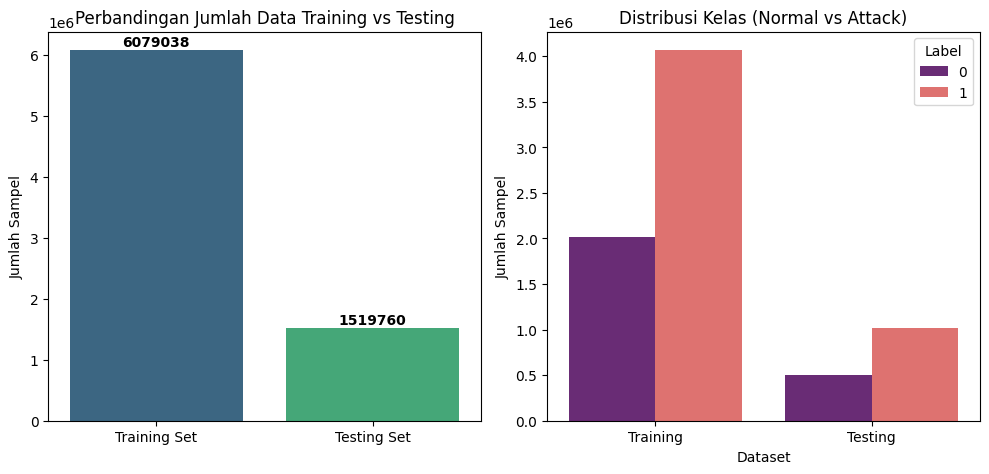

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

labels = ['Training Set', 'Testing Set']
counts = [len(X_train), len(X_test)]

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
sns.barplot(x=labels, y=counts, palette='viridis')
plt.title('Perbandingan Jumlah Data Training vs Testing')
plt.ylabel('Jumlah Sampel')
for i, v in enumerate(counts):
    plt.text(i, v + (max(counts)*0.01), str(v), ha='center', fontweight='bold')

plt.subplot(1, 2, 2)
train_dist = pd.DataFrame({'Label': y_train, 'Dataset': 'Training'})
test_dist = pd.DataFrame({'Label': y_test, 'Dataset': 'Testing'})
dist_df = pd.concat([train_dist, test_dist])

sns.countplot(data=dist_df, x='Dataset', hue='Label', palette='magma')
plt.title('Distribusi Kelas (Normal vs Attack)')
plt.ylabel('Jumlah Sampel')

plt.tight_layout()
plt.show()

In [34]:
import numpy as np

# Cek apakah ada NaN atau Infinity di data training
print("Apakah ada NaN:", np.isnan(X_train).any())
print("Apakah ada Infinity:", np.isinf(X_train).any())

# Jika Anda ingin tahu kolom mana yang bermasalah:
if np.isinf(X_train).any() or np.isnan(X_train).any():
    problem_cols = np.where(np.isinf(X_train).any(axis=0) | np.isnan(X_train).any(axis=0))[0]
    print(f"Kolom index yang bermasalah: {problem_cols}")

Apakah ada NaN: False
Apakah ada Infinity: False


In [35]:
import gc
from minisom import MiniSom

X_train = np.nan_to_num(X_train, nan=0.0, posinf=1.0, neginf=-1.0)

X_train = X_train.astype('float32')

X_train_sub = X_train[:1000000]
y_train_sub = y_train[:1000000]

som = MiniSom(x=15, y=15, input_len=X_train.shape[1], 
              sigma=1.5, learning_rate=0.5, random_seed=42)

som.random_weights_init(X_train_sub)

som.train_random(X_train_sub, 1000000, verbose=True)

 [ 1000000 / 1000000 ] 100% - 0:00:00 left 

i:\sem8\Rkysa Apl Terdistribusi\NIDS\env\Lib\site-packages\minisom.py:536: RuntimeWarning: invalid value encountered in sqrt
  return sqrt(-2 * cross_term + input_data_sq + weights_flat_sq.T)



 quantization error: 0.2767099179760466


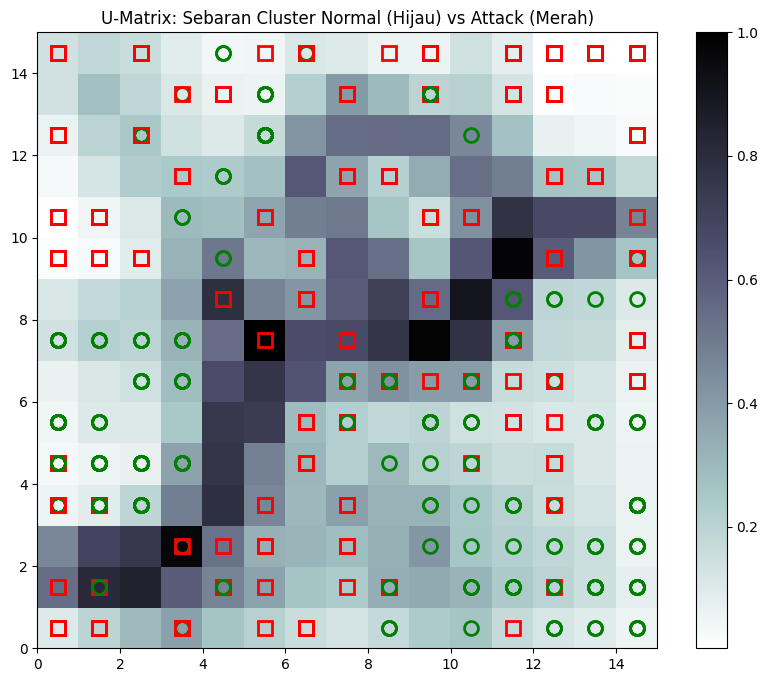

In [36]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
# Memplot jarak antar neuron (U-Matrix)
plt.pcolor(som.distance_map().T, cmap='bone_r') 
plt.colorbar()

markers = ['o', 's'] 
colors = ['g', 'r']   

for i, x in enumerate(X_train_sub[:1000]):
    w = som.winner(x)
    plt.plot(w[0]+0.5, w[1]+0.5, markers[y_train[i]], 
             markerfacecolor='None', markeredgecolor=colors[y_train[i]], 
             markersize=10, markeredgewidth=2)

plt.title('U-Matrix: Sebaran Cluster Normal (Hijau) vs Attack (Merah)')
plt.show()

In [37]:
qe = som.quantization_error(X_train_sub)
print(f"Quantization Error: {qe}")

Quantization Error: 0.2767099179760466


In [38]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

label_map = som.labels_map(X_train_sub, y_train_sub)
winner_labels = np.zeros((15, 15))

for position, labels in label_map.items():
    winner_labels[position] = labels.most_common(1)[0][0]
unique, counts = np.unique(winner_labels, return_counts=True)
print("Distribusi label pada neuron SOM:", dict(zip(unique, counts)))
y_pred = []
for x in X_test[:500000]: 
    winner = som.winner(x)
    y_pred.append(winner_labels[winner])

print(classification_report(y_test[:500000], y_pred))

Distribusi label pada neuron SOM: {0.0: 131, 1.0: 94}
              precision    recall  f1-score   support

           0       0.90      0.92      0.91    165808
           1       0.96      0.95      0.96    334192

    accuracy                           0.94    500000
   macro avg       0.93      0.94      0.93    500000
weighted avg       0.94      0.94      0.94    500000



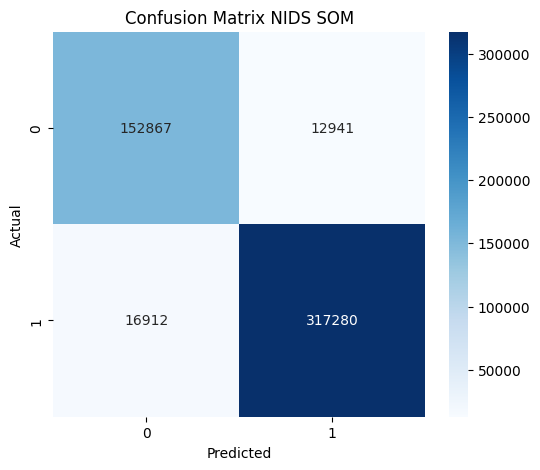

In [39]:
cm = confusion_matrix(y_test[:500000], y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix NIDS SOM')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [40]:
import joblib
import os

if not os.path.exists('../model'):
    os.makedirs('../model')

export_data = {
    'model': som,
    'scaler': scaler,
    'winner_labels': winner_labels
}

model_path = '../model/nids_som.joblib'
joblib.dump(export_data, model_path)

print(f"Model lengkap berhasil disimpan menggunakan joblib di: {model_path}")

Model lengkap berhasil disimpan menggunakan joblib di: ../model/nids_som.joblib
